In [1]:
# ‐*‐ coding: utf‐8 ‐*‐
"""Bước 1: đọc tệp dữ liệu và nhìn qua một lượt.

Chú thích trong tệp viết tiếng Việt có dấu, nhưng phần in ra màn hình cố ý
viết không dấu. Cửa sổ lệnh Windows thường không hiện được chữ có dấu.
"""

import pandas as pd

# Đọc tệp CSV thành một bảng. Tên df là viết tắt quen dùng của data frame.
#df = pd.read_csv("data/gia_nha.csv")
df = pd.read_csv("data/gia_nha.csv")

print("Kich thuoc bang (so dong, so cot):", df.shape)
print()

print("Nam dong dau tien:")
print(df.head())
print()

print("Ten cac cot:", list(df.columns))
print()

print("Thong ke nhanh cot dien_tich va cot gia:")
print(df[["dien_tich", "gia"]].describe().round(2))
print()

print("So o bi thieu trong tung cot:")
print(df.isna().sum())

Kich thuoc bang (so dong, so cot): (60, 4)

Nam dong dau tien:
   dien_tich  so_phong  tuoi_nha   gia
0       35.5         1        18  3.00
1       37.6         2         7  3.87
2       49.4         2        20  4.25
3       49.0         2        16  4.60
4       49.9         1        12  3.99

Ten cac cot: ['dien_tich', 'so_phong', 'tuoi_nha', 'gia']

Thong ke nhanh cot dien_tich va cot gia:
       dien_tich    gia
count      60.00  60.00
mean       77.73   6.49
std        20.22   1.64
min        35.50   3.00
25%        63.02   5.16
50%        75.10   6.40
75%        91.88   7.70
max       117.50   9.74

So o bi thieu trong tung cot:
dien_tich    0
so_phong     0
tuoi_nha     0
gia          0
dtype: int64


# Bài tập 1: Lọc ra nhóm căn hộ lớn


In [2]:
import pandas as pd

# 1. Đọc bộ dữ liệu
#df = pd.read_csv("data/gia_nha.csv")
df = pd.read_csv("data/gia_nha.csv")

# 2. Lọc các căn hộ có diện tích lớn hơn 100 m²
nhom_lon = df[df["dien_tich"] > 100]

# 3. Tính số lượng và giá trung bình
so_luong = len(nhom_lon)
gia_trung_binh = nhom_lon["gia"].mean()

# 4. In ra hai con số kết quả
print("Số căn có diện tích > 100m²:", so_luong)
print(f"Giá trung bình của nhóm (> 100m²): {gia_trung_binh:.4f} tỷ đồng")

Số căn có diện tích > 100m²: 10
Giá trung bình của nhóm (> 100m²): 8.9620 tỷ đồng


# Bài tập 2: Vẽ biểu đồ phân tán theo số phòng

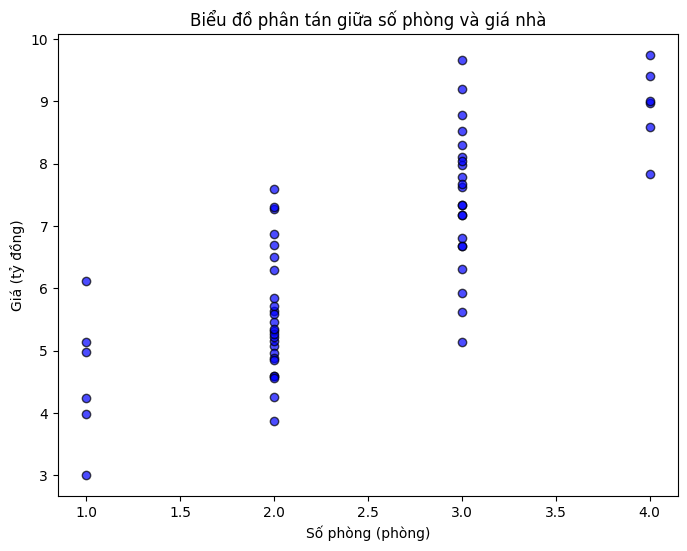

Nhận xét: Giá nhà có xu hướng đồng biến (tăng) theo số lượng phòng; căn hộ càng có nhiều phòng thì giá bán trung bình càng cao.


In [3]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Đọc bộ dữ liệu
#df = pd.read_csv("data/gia_nha.csv")
df = pd.read_csv("data/gia_nha.csv")

# 2. Vẽ biểu đồ phân tán giữa số phòng và giá nhà
plt.figure(figsize=(8, 6))
plt.scatter(df["so_phong"], df["gia"], color="blue", alpha=0.7, edgecolors="k")

# 3. Đặt nhãn cho trục hoành, trục tung và tiêu đề cho biểu đồ
plt.xlabel("Số phòng (phòng)")
plt.ylabel("Giá (tỷ đồng)")
plt.title("Biểu đồ phân tán giữa số phòng và giá nhà")

# 4. Lưu biểu đồ thành tệp ảnh bai2.png trước khi hiển thị (plt.show)
plt.savefig("bai2.png", dpi=150, bbox_inches="tight")
plt.show()

# 5. In câu nhận xét xu hướng ra màn hình console
print(
    "Nhận xét: Giá nhà có xu hướng đồng biến (tăng) theo số lượng phòng; căn hộ càng có nhiều phòng thì giá bán trung bình càng cao."
)

# Bài tập 3: Đổi biến đầu vào sang tuổi nhà

Hệ số góc w = -0.037858
Hệ số chặn b = 6.983593


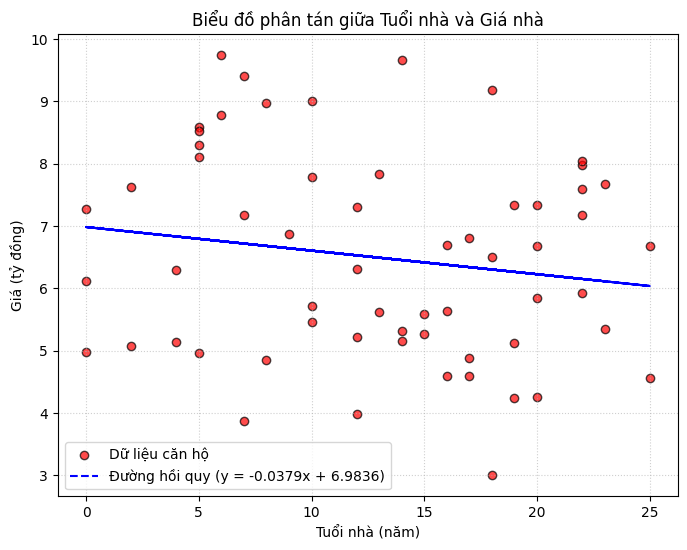


--- NHẬN XÉT VÀ GIẢI THÍCH ---
1. Nhận xét dấu: Hệ số w mang dấu âm (w = -0.037858).
2. Giải thích: Dấu âm thể hiện mối quan hệ nghịch biến. Khi tuổi nhà tăng thêm 1 năm,
   giá nhà có xu hướng giảm đi trung bình khoảng 0.037858 tỷ đồng (~37.86 triệu đồng)
   do sự hao mòn theo thời gian về chất lượng công trình và hạ tầng nội thất.


In [4]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Đọc bộ dữ liệu
df = pd.read_csv("data/gia_nha.csv")

# 2. Trích xuất biến đầu vào x (tuoi_nha) và biến mục tiêu y (gia)
x_all = df["tuoi_nha"].to_numpy()
y_all = df["gia"].to_numpy()

# 3. Tính giá trị trung bình
x_tb = x_all.mean()
y_tb = y_all.mean()

# 4. Áp dụng công thức bình phương tối thiểu (OLS)
tu_so = ((x_all - x_tb) * (y_all - y_tb)).sum()
mau_so = ((x_all - x_tb) ** 2).sum()

w = tu_so / mau_so
b = y_tb - w * x_tb

# 5. In kết quả với 6 chữ số sau dấu phẩy
print(f"Hệ số góc w = {w:.6f}")
print(f"Hệ số chặn b = {b:.6f}")

# 6. Vẽ biểu đồ phân tán và đường hồi quy
plt.figure(figsize=(8, 6))
plt.scatter(
    df["tuoi_nha"],
    df["gia"],
    color="red",
    alpha=0.7,
    edgecolors="k",
    label="Dữ liệu căn hộ",
)
plt.plot(
    x_all,
    w * x_all + b,
    color="blue",
    linestyle="--",
    label=f"Đường hồi quy (y = {w:.4f}x + {b:.4f})",
)
plt.xlabel("Tuổi nhà (năm)")
plt.ylabel("Giá (tỷ đồng)")
plt.title("Biểu đồ phân tán giữa Tuổi nhà và Giá nhà")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)

# Lưu biểu đồ thành tệp ảnh
plt.savefig("bai3_tuoi_nha.png", dpi=150, bbox_inches="tight")
plt.show()

# 7. In câu giải thích và nhận xét
print("\n--- NHẬN XÉT VÀ GIẢI THÍCH ---")
print("1. Nhận xét dấu: Hệ số w mang dấu âm (w = -0.037858).")
print(
    "2. Giải thích: Dấu âm thể hiện mối quan hệ nghịch biến. Khi tuổi nhà tăng thêm 1 năm,"
)
print(
    "   giá nhà có xu hướng giảm đi trung bình khoảng 0.037858 tỷ đồng (~37.86 triệu đồng)"
)
print(
    "   do sự hao mòn theo thời gian về chất lượng công trình và hạ tầng nội thất."
)

# Bài tập 4: Thêm số phòng vào mô hình

In [5]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

# 1. Đọc bộ dữ liệu
df = pd.read_csv("data/gia_nha.csv")

# 2. Chọn 2 đặc trưng đầu vào (dien_tich, so_phong) và biến mục tiêu (gia)
X = df[["dien_tich", "so_phong"]]
y = df["gia"]

# 3. Chia tập dữ liệu (80% Train - 48 căn, 20% Test - 12 căn)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Khởi tạo và huấn luyện mô hình
mo_hinh = LinearRegression()
mo_hinh.fit(X_train, y_train)

# 5. Dự đoán trên tập kiểm tra và tính chỉ số R²
y_pred = mo_hinh.predict(X_test)
r2_multi = r2_score(y_test, y_pred)

# 6. In ra kết quả
print(f"Hệ số R² trên tập kiểm tra (2 biến: dien_tich + so_phong): {r2_multi:.4f}")

# 7. In phần so sánh và đánh giá
print("\n--- SO SÁNH VÀ ĐÁNH GIÁ ---")
print(f"- R² mô hình 1 biến (dien_tich)          : 0.9622")
print(f"- R² mô hình 2 biến (dien_tich + so_phong): {r2_multi:.4f}")
print(
    f"- Mức chênh lệch                             : +{r2_multi - 0.9622:.4f} (+{(r2_multi - 0.9622)*100:.2f}%)"
)
print(
    "\nĐánh giá: Việc thêm cột so_phong LÀ ĐÁNG. Mặc dù diện tích đã giải thích được phần lớn"
)
print(
    "biến động giá (96.22%), việc bổ sung số phòng giúp mô hình nắm bắt thêm cấu trúc không gian"
)
print(
    "nội thất, nâng khả năng giải thích lên 96.98% mà không làm tăng độ phức tạp tính toán đáng kể."
)

Hệ số R² trên tập kiểm tra (2 biến: dien_tich + so_phong): 0.9698

--- SO SÁNH VÀ ĐÁNH GIÁ ---
- R² mô hình 1 biến (dien_tich)          : 0.9622
- R² mô hình 2 biến (dien_tich + so_phong): 0.9698
- Mức chênh lệch                             : +0.0076 (+0.76%)

Đánh giá: Việc thêm cột so_phong LÀ ĐÁNG. Mặc dù diện tích đã giải thích được phần lớn
biến động giá (96.22%), việc bổ sung số phòng giúp mô hình nắm bắt thêm cấu trúc không gian
nội thất, nâng khả năng giải thích lên 96.98% mà không làm tăng độ phức tạp tính toán đáng kể.


# Bài tập 5: Thử hai tốc độ học khác

In [6]:
import numpy as np
import pandas as pd

# 1. Đọc bộ dữ liệu
df = pd.read_csv("data/gia_nha.csv")
X = df["dien_tich"].values
y = df["gia"].values

# 2. Chuẩn hóa Z-score để Gradient Descent hoạt động ổn định
X_norm = (X - X.mean()) / X.std()


# 3. Định nghĩa hàm chạy Gradient Descent
def run_gradient_descent(toc_do_hoc, so_vong=200):
    w = 0.0
    b = 0.0
    N = len(y)

    for vong in range(1, so_vong + 1):
        y_pred = w * X_norm + b
        error = y_pred - y

        # Tính đạo hàm (Gradient)
        dw = (2 / N) * np.sum(error * X_norm)
        db = (2 / N) * np.sum(error)

        # Cập nhật trọng số
        w -= toc_do_hoc * dw
        b -= toc_do_hoc * db

    # Tính MSE ở vòng lặp cuối cùng (vòng 200)
    mse = np.mean((y_pred - y) ** 2)
    return mse


# 4. Chạy thực nghiệm với 2 tốc độ học theo yêu cầu
mse_0001 = run_gradient_descent(0.001, 200)
mse_102 = run_gradient_descent(1.02, 200)

print(f"MSE ở vòng 200 với tốc độ học 0.001 : {mse_0001:.4f}")
print(f"MSE ở vòng 200 với tốc độ học 1.02  : {mse_102:.4f}")

# 5. Thực nghiệm bổ sung: Thử nghiệm với các mức tốc độ học khác
print("\n--- THỰC NGHIỆM BỔ SUNG (DÒ RANH GIỚI HỘI TỤ) ---")
for lr in [0.1, 0.5, 0.9, 0.99, 1.0, 1.001]:
    mse = run_gradient_descent(lr, 200)
    print(f"Tốc độ học {lr:<5} | MSE ở vòng 200: {mse:.4f}")

MSE ở vòng 200 với tốc độ học 0.001 : 20.2979
MSE ở vòng 200 với tốc độ học 1.02  : 268483526.2887

--- THỰC NGHIỆM BỔ SUNG (DÒ RANH GIỚI HỘI TỤ) ---
Tốc độ học 0.1   | MSE ở vòng 200: 0.1790
Tốc độ học 0.5   | MSE ở vòng 200: 0.1790
Tốc độ học 0.9   | MSE ở vòng 200: 0.1790
Tốc độ học 0.99  | MSE ở vòng 200: 0.1934
Tốc độ học 1.0   | MSE ở vòng 200: 44.8113
Tốc độ học 1.001 | MSE ở vòng 200: 99.0347


# Bài tập 6: Viết hàm dự đoán có cảnh báo

In [7]:
def du_doan_gia(dien_tich):
    # Sử dụng hai hệ số w và b đã huấn luyện từ mục 5
    w = 0.078367
    b = 0.401752

    # Cảnh báo nếu diện tích nằm ngoài khoảng dữ liệu thu thập [35.5, 117.5] m²
    if dien_tich < 35.5 or dien_tich > 117.5:
        print(
            f"[CẢNH BÁO] Diện tích {dien_tich}m² nằm ngoài khoảng dữ liệu quan sát (35.5 - 117.5 m²). Kết quả dự đoán chỉ là suy đoán kéo dài (extrapolation)!"
        )

    # Tính toán giá theo phương trình hồi quy tuyến tính: y = w * x + b
    gia_du_doan = w * dien_tich + b
    return gia_du_doan


# Gọi thử nghiệm với 3 mốc diện tích: 60 m², 80 m² và 200 m²
cac_moc = [60, 80, 200]

for dt in cac_moc:
    gia = du_doan_gia(dt)
    print(f"-> Giá dự đoán cho căn hộ {dt}m² là: {gia:.3f} tỷ đồng\n")

-> Giá dự đoán cho căn hộ 60m² là: 5.104 tỷ đồng

-> Giá dự đoán cho căn hộ 80m² là: 6.671 tỷ đồng

[CẢNH BÁO] Diện tích 200m² nằm ngoài khoảng dữ liệu quan sát (35.5 - 117.5 m²). Kết quả dự đoán chỉ là suy đoán kéo dài (extrapolation)!
-> Giá dự đoán cho căn hộ 200m² là: 16.075 tỷ đồng

